In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ratings = pd.read_csv(r"C:\Users\Welcome\Downloads\ml exp 9 dataset\ml-latest-small\ratings.csv")
movies = pd.read_csv(r"C:\Users\Welcome\Downloads\ml exp 9 dataset\ml-latest-small\movies.csv")
tags = pd.read_csv(r"C:\Users\Welcome\Downloads\ml exp 9 dataset\ml-latest-small\tags.csv")
links = pd.read_csv(r"C:\Users\Welcome\Downloads\ml exp 9 dataset\ml-latest-small\links.csv")

In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
ratings.shape

(100836, 4)

In [7]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [8]:
print("Total Users:", ratings['userId'].nunique())
print("Total Movies:", ratings['movieId'].nunique())

Total Users: 610
Total Movies: 9724


In [9]:
user_item_matrix = ratings.pivot(index="userId",
                                 columns="movieId",
                                 values="rating")

In [10]:
user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [12]:
user_similarity = cosine_similarity(user_item_matrix_filled)

In [13]:
user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item_matrix.index,
                                  columns=user_item_matrix.index)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [14]:
user_id = 5

similar_users = user_similarity_df[user_id].sort_values(ascending=False)

top_similar_users = similar_users.iloc[1:6]

print(top_similar_users)

userId
470    0.520671
229    0.517333
565    0.511325
235    0.507638
142    0.474124
Name: 5, dtype: float64


In [15]:
def predict_rating(user_id, movie_id):

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    ratings = user_item_matrix_filled.loc[similar_users.index, movie_id]

    similarity_scores = similar_users.values

    if ratings.sum() == 0:
        return 0

    predicted_rating = np.dot(similarity_scores, ratings) / similarity_scores.sum()

    return predicted_rating

In [16]:
predict_rating(5, 50)

np.float64(2.56381897030347)

In [17]:
def recommend_movies(user_id, n=5):

    user_ratings = user_item_matrix.loc[user_id]

    unseen_movies = user_ratings[user_ratings.isna()].index

    predictions = {}

    for movie in unseen_movies:
        predictions[movie] = predict_rating(user_id, movie)

    recommended = sorted(predictions.items(),
                         key=lambda x: x[1],
                         reverse=True)

    return recommended[:n]

In [18]:
recommend_movies(5,5)

[(356, np.float64(4.406270967883055)),
 (377, np.float64(4.200560974930449)),
 (539, np.float64(3.048702015214722)),
 (480, np.float64(3.005927752464419)),
 (593, np.float64(2.7569701207904154))]

In [19]:
recommended = recommend_movies(5,5)

movie_ids = [movie[0] for movie in recommended]

movies[movies['movieId'].isin(movie_ids)][['movieId','title']]

,movieId,title
314,356,Forrest Gump (1994)
334,377,Speed (1994)
418,480,Jurassic Park (1993)
472,539,Sleepless in Seattle (1993)
510,593,"Silence of the Lambs, The (1991)"


In [20]:
y_true = []
y_pred = []

for row in ratings.itertuples():

    pred = predict_rating(row.userId, row.movieId)

    y_true.append(row.rating)
    y_pred.append(pred)

In [21]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 2.464558386054085


In [22]:
mae = mean_absolute_error(y_true, y_pred)
print("MAE:", mae)

MAE: 2.1030707719256516


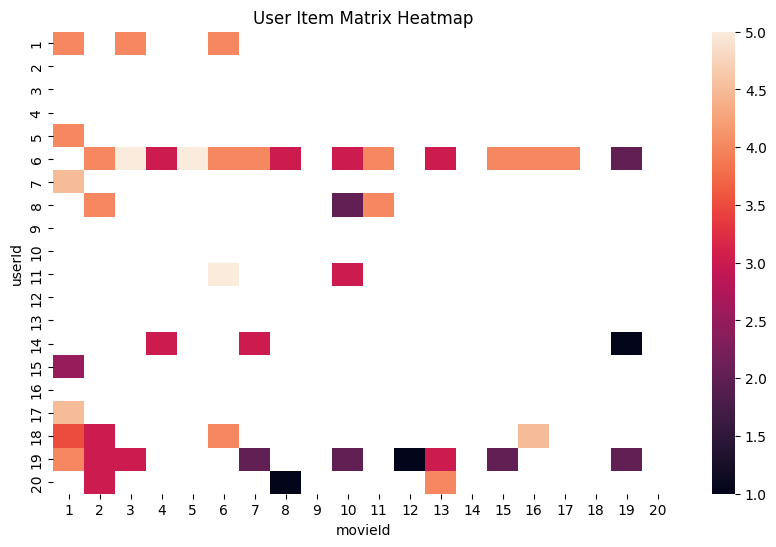

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix.iloc[:20,:20])
plt.title("User Item Matrix Heatmap")
plt.show()

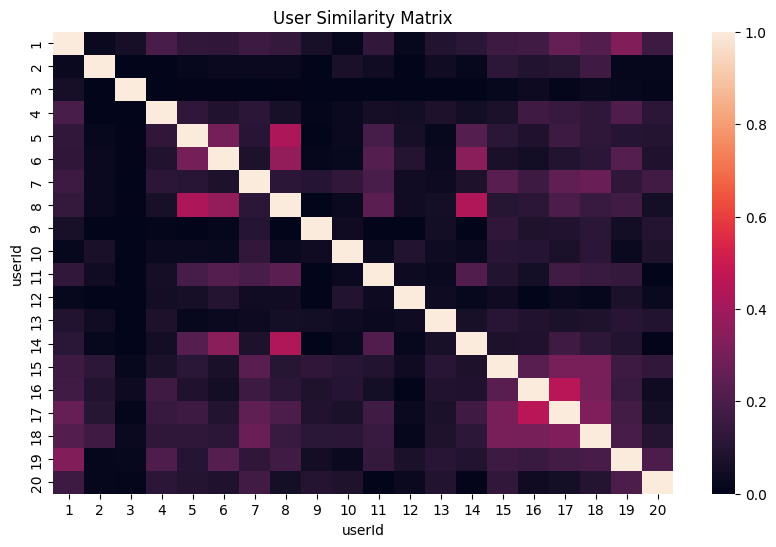

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(user_similarity_df.iloc[:20,:20])
plt.title("User Similarity Matrix")
plt.show()

This is Scenario 2 – Item-Based Collaborative Filtering.
In Scenario 1, we recommended movies using similar users.
In Scenario 2, we recommend movies using similar items (movies).

In [25]:
recommended_movies = recommend_movies(5,10)

In [26]:
rec_df = pd.DataFrame(recommended_movies, columns=['movieId','score'])

In [27]:
rec_df = rec_df.merge(movies, on='movieId')

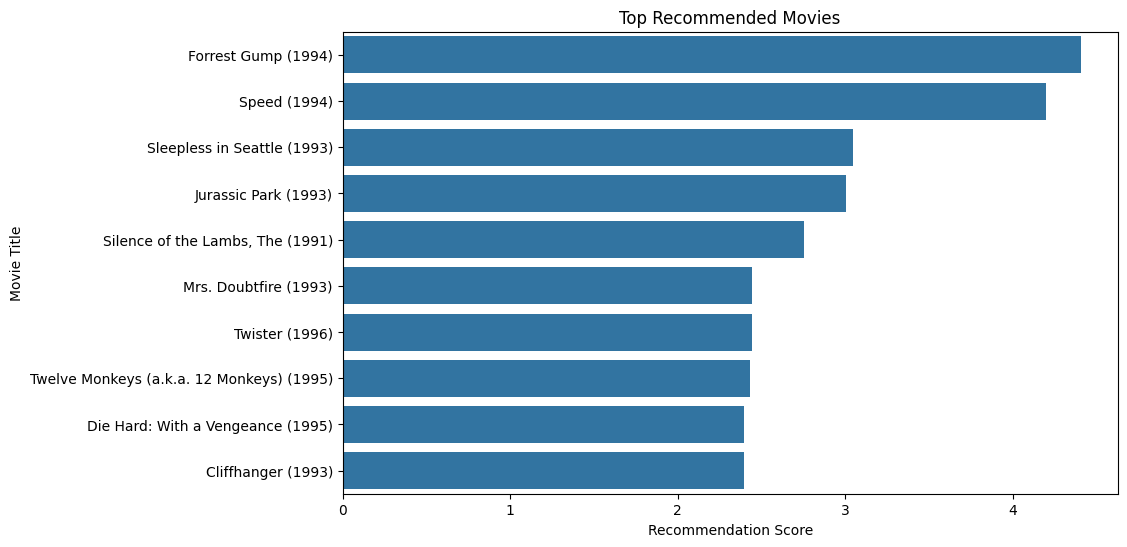

In [ ]:
# Get recommendations
recommended_movies = recommend_movies(5,10)

# Convert to dataframe
rec_df = pd.DataFrame(recommended_movies, columns=['movieId','score'])

# Add movie titles
rec_df = rec_df.merge(movies, on='movieId')

# Plot
plt.figure(figsize=(10,6))

sns.barplot(x='score', y='title', data=rec_df)

plt.title("Top Recommended Movies")
plt.xlabel("Recommendation Score")
plt.ylabel("Movie Title")

plt.show()